# Semaines 1 & 2 - Nettoyage & Analyse Exploratoire (EDA)
## Dataset : Films & Séries Netflix

**Programme :** AnalystLab Africa - Data Analytics Internship (Batch C)

**Source :** https://www.kaggle.com/datasets/shivamb/netflix-shows

Catalogue des films et séries disponibles sur Netflix (8 807 titres, jusqu'en septembre 2021).

## Tâche 1 - Compréhension du jeu de données

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv('data/netflix_titles.csv')
data.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [2]:
print("Dimensions :", data.shape)
print("\nTypes de données :")
print(data.dtypes)

Dimensions : (8807, 12)

Types de données :
show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object


In [3]:
print("show_id est-il unique ?", data['show_id'].is_unique)

show_id est-il unique ? True


**Structure du dataset :**

| Colonne | Type | Rôle |
|---|---|---|
| show_id | texte | Identifiant unique du titre (clé primaire) |
| type | catégoriel | "Movie" ou "TV Show" |
| title | texte | Titre du contenu |
| director | texte | Réalisateur(s) |
| cast | texte | Acteurs principaux |
| country | catégoriel | Pays de production (parfois plusieurs, séparés par des virgules) |
| date_added | date | Date d'ajout au catalogue Netflix |
| release_year | numérique | Année de sortie |
| rating | catégoriel | Classification d'âge (TV-MA, PG-13...) |
| duration | texte | Durée : minutes pour les films, saisons pour les séries |
| listed_in | catégoriel | Genres/catégories (plusieurs, séparés par des virgules) |
| description | texte | Résumé du contenu |

- **Variable numérique :** release_year (duration le deviendra après nettoyage)
- **Variables catégorielles :** type, country, rating, listed_in
- **Clé primaire :** show_id (vérifié unique)

Contrairement au dataset e-commerce (transactions), il s'agit ici d'un **catalogue** : une ligne = un titre, pas d'événements répétés.

## Tâche 2 - Nettoyage des données
### 2.1 Valeurs manquantes

In [4]:
print("Valeurs manquantes par colonne :")
print(data.isnull().sum())
print(f"\n% director manquants : {data['director'].isnull().mean()*100:.1f}%")

Valeurs manquantes par colonne :
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

% director manquants : 29.9%


**Décisions :**

| Colonne | Manquants | Traitement | Justification |
|---|---|---|---|
| director | 2 634 (30 %) | Remplacés par "Unknown" | Supprimer ferait perdre 30 % du catalogue ; l'information descriptive manquante n'invalide pas la ligne |
| cast | 825 | Remplacés par "Unknown" | Même logique |
| country | 831 | Remplacés par "Unknown" | Même logique ; exclus des analyses par pays |
| date_added | 10 | Conservés en NaT | Volume négligeable, exclus des analyses temporelles |
| rating | 4 (+3 corrigés) | Remplacés par "Unknown" | Volume négligeable |
| duration | 3 | Récupérés depuis `rating` (voir 2.3) | Erreur de décalage de colonne |

**Différence clé avec le dataset e-commerce :** ici on privilégie l'**imputation** ("Unknown") plutôt que la suppression, car chaque ligne est un titre unique du catalogue - supprimer, c'est perdre le titre entier alors que la plupart de ses champs sont valides.

### 2.2 Doublons

In [5]:
print("Doublons exacts :", data.duplicated().sum())
print("Doublons titre + type :", data.duplicated(subset=['title','type']).sum())

Doublons exacts : 0
Doublons titre + type : 0


Aucun doublon : `show_id` est unique et aucune combinaison titre + type n'est répétée. Rien à supprimer, mais la vérification devait être faite et documentée.

### 2.3 Validation des données : lignes décalées

Trois films ont leur **durée stockée dans la colonne `rating`** ("74 min", "84 min", "66 min") et une durée vide : une erreur de saisie à la source. On remet les valeurs à leur place.

In [6]:
decale = data['duration'].isnull() & data['rating'].str.contains('min', na=False)
print(data.loc[decale, ['title','rating','duration']])

# Correction : la valeur retourne dans duration, rating devient manquant
data.loc[decale, 'duration'] = data.loc[decale, 'rating']
data.loc[decale, 'rating'] = None

                                     title  rating duration
5541                       Louis C.K. 2017  74 min      NaN
5794                 Louis C.K.: Hilarious  84 min      NaN
5813  Louis C.K.: Live at the Comedy Store  66 min      NaN


### 2.4 Traitement des manquants et standardisation

In [7]:
# Imputation des champs descriptifs
for col in ['director', 'cast', 'country', 'rating']:
    data[col] = data[col].fillna('Unknown')

# date_added : espaces parasites (88 lignes) puis conversion en datetime
data['date_added'] = pd.to_datetime(data['date_added'].str.strip(),
                                    format='%B %d, %Y', errors='coerce')

# Nettoyage des espaces dans les champs texte
for col in ['title', 'country', 'listed_in']:
    data[col] = data[col].str.strip()

print(data.isnull().sum())

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           0
duration         0
listed_in        0
description      0
dtype: int64


### 2.5 Colonnes calculées : séparer la durée mixte

`duration` mélange deux unités : "90 min" (films) et "2 Seasons" (séries). On la scinde en une valeur numérique et une unité.

In [8]:
data['duration_valeur'] = data['duration'].str.extract(r'(\d+)').astype(int)
data['duration_unite'] = data['duration'].str.extract(r'(min|Season)')[0].map(
    {'min': 'minutes', 'Season': 'saisons'})
data['annee_ajout'] = data['date_added'].dt.year

data[['type','duration','duration_valeur','duration_unite']].head()

,type,duration,duration_valeur,duration_unite
0,Movie,90 min,90,minutes
1,TV Show,2 Seasons,2,saisons
2,TV Show,1 Season,1,saisons
3,TV Show,1 Season,1,saisons
4,TV Show,2 Seasons,2,saisons


### 2.6 Résumé du nettoyage

| Problème identifié | Action effectuée | Lignes concernées |
|---|---|---|
| director/cast/country manquants | Imputés par "Unknown" | 2 634 / 825 / 831 |
| rating manquants | Imputés par "Unknown" | 7 |
| Durées décalées dans rating | Valeurs replacées dans duration | 3 |
| Espaces parasites dans date_added | Supprimés puis conversion datetime | 88 |
| duration en unités mixtes | Scindée en valeur numérique + unité | toutes |
| Doublons | Vérifiés : aucun | 0 |

**Résultat : les 8 807 lignes sont conservées** (0 suppression) - le nettoyage a corrigé et structuré sans perte d'information.

In [9]:
data.to_csv('data/netflix_titles_clean.csv', index=False)
print(f"Dataset nettoyé sauvegardé : {data.shape}")

Dataset nettoyé sauvegardé : (8807, 15)


## Tâche 3 - Analyse Exploratoire (EDA)
### 3.1 Statistiques descriptives

In [10]:
print("Durée des films (minutes) :")
print(data[data['type']=='Movie']['duration_valeur'].describe().round(1))
print("\nNombre de saisons des séries :")
print(data[data['type']=='TV Show']['duration_valeur'].describe().round(1))
print("\nAnnée de sortie :")
print(data['release_year'].describe().round(1))

Durée des films (minutes) :
count    6131.0
mean       99.6
std        28.3
min         3.0
25%        87.0
50%        98.0
75%       114.0
max       312.0
Name: duration_valeur, dtype: float64

Nombre de saisons des séries :
count    2676.0
mean        1.8
std         1.6
min         1.0
25%         1.0
50%         1.0
75%         2.0
max        17.0
Name: duration_valeur, dtype: float64

Année de sortie :
count    8807.0
mean     2014.2
std         8.8
min      1925.0
25%      2013.0
50%      2017.0
75%      2019.0
max      2021.0
Name: release_year, dtype: float64


### 3.2 Répartition Films vs Séries

In [11]:
rep = data['type'].value_counts()
print(rep)
print((data['type'].value_counts(normalize=True)*100).round(1))

type
Movie      6131
TV Show    2676
Name: count, dtype: int64
type
Movie      69.6
TV Show    30.4
Name: proportion, dtype: float64


### 3.3 Contenu ajouté par année

In [12]:
ajouts = data.groupby(['annee_ajout','type']).size().unstack(fill_value=0)
ajouts

type,Movie,TV Show
annee_ajout,,
2008.0,1,1
2009.0,2,0
2010.0,1,0
2011.0,13,0
2012.0,3,0
2013.0,6,5
2014.0,19,5
2015.0,56,26
2016.0,253,176


### 3.4 Principaux pays producteurs

In [13]:
# Un titre peut avoir plusieurs pays : on les sépare avant de compter
pays = data[data['country']!='Unknown']['country'].str.split(', ').explode()
pays.value_counts().head(10)

country
United States     3689
India             1046
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64

### 3.5 Classifications d'âge les plus fréquentes

In [14]:
print(data[data['rating'].notnull()]['rating'].value_counts().head(8))
part_adulte = data['rating'].isin(['TV-MA','TV-14']).mean()*100
print(f"\nPart TV-MA + TV-14 (contenu ado/adulte) : {part_adulte:.1f}%")

rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
TV-Y7     334
TV-Y      307
PG        287
Name: count, dtype: int64

Part TV-MA + TV-14 (contenu ado/adulte) : 60.9%


### 3.6 Genres les plus fréquents

In [15]:
genres = data['listed_in'].str.split(', ').explode()
genres.value_counts().head(10)

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

### 3.7 Format des séries

In [16]:
series = data[data['type']=='TV Show']
part_1saison = (series['duration_valeur']==1).mean()*100
print(f"Séries à une seule saison : {part_1saison:.1f}%")

Séries à une seule saison : 67.0%


## Tâche 4 - Visualisations

Palette : bleu `#2a78d6` pour les mesures de volume, vert d'eau `#1baf7a` pour distinguer les séries des films.

In [17]:
import os
os.makedirs('visualisations', exist_ok=True)

BLEU, AQUA = '#2a78d6', '#1baf7a'
ENCRE, GRIS = '#0b0b0b', '#898781'
plt.rcParams.update({
    'figure.autolayout': True, 'axes.grid': True, 'grid.color': '#e1e0d9',
    'grid.linewidth': 0.8, 'axes.edgecolor': '#c3c2b7', 'axes.labelcolor': GRIS,
    'xtick.color': GRIS, 'ytick.color': GRIS, 'axes.titlecolor': ENCRE,
    'axes.spines.top': False, 'axes.spines.right': False})

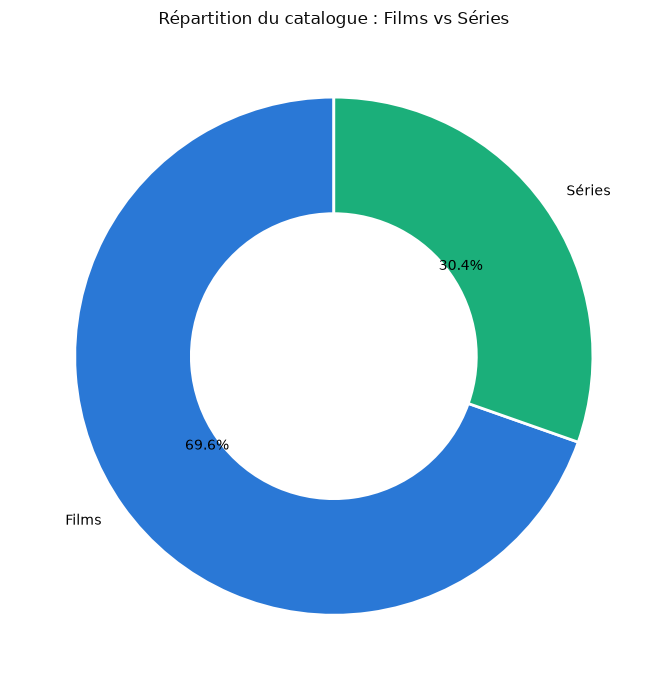

In [18]:
# Viz 1 : répartition Films vs Séries (donut)
fig, ax = plt.subplots(figsize=(7,7))
rep = data['type'].value_counts()
ax.pie(rep, labels=['Films', 'Séries'], autopct='%1.1f%%', startangle=90,
       colors=[BLEU, AQUA], wedgeprops={'width': 0.45, 'edgecolor': 'white', 'linewidth': 2})
ax.set_title('Répartition du catalogue : Films vs Séries')
fig.savefig('visualisations/viz1_films_vs_series.png', dpi=120)
plt.show()

**Constat :** les films dominent le catalogue avec 69,6 % des titres contre 30,4 % pour les séries.

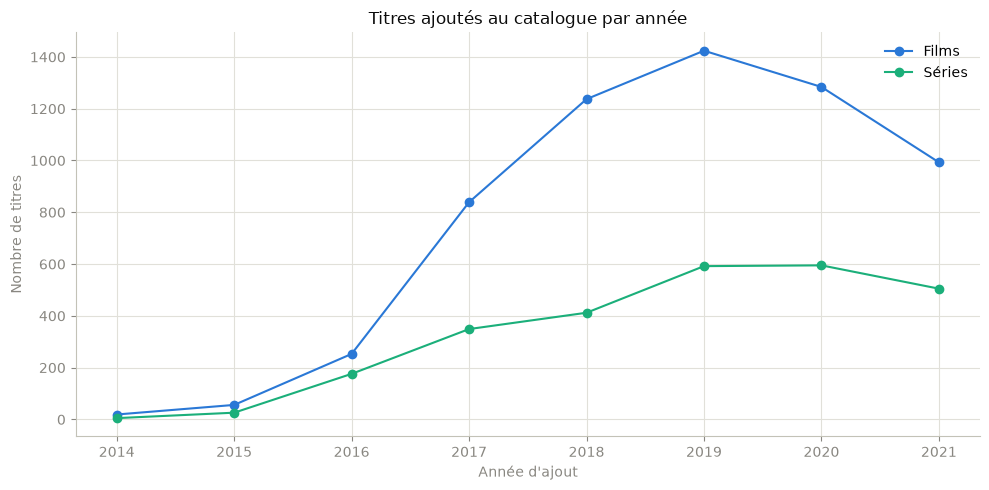

In [19]:
# Viz 2 : contenu ajouté par année, par type
fig, ax = plt.subplots(figsize=(10,5))
ajouts_recent = ajouts.loc[2014:]
ax.plot(ajouts_recent.index, ajouts_recent['Movie'], marker='o', color=BLEU, label='Films')
ax.plot(ajouts_recent.index, ajouts_recent['TV Show'], marker='o', color=AQUA, label='Séries')
ax.set_title('Titres ajoutés au catalogue par année')
ax.set_xlabel('Année d\'ajout'); ax.set_ylabel('Nombre de titres')
ax.legend(frameon=False)
fig.savefig('visualisations/viz2_ajouts_par_annee.png', dpi=120)
plt.show()

**Constat :** croissance explosive de 2016 à 2019 (pic : 2 016 titres en 2019), puis repli en 2020-2021, cohérent avec l'arrêt des tournages pendant la pandémie. 2021 est partiel (données arrêtées en septembre).

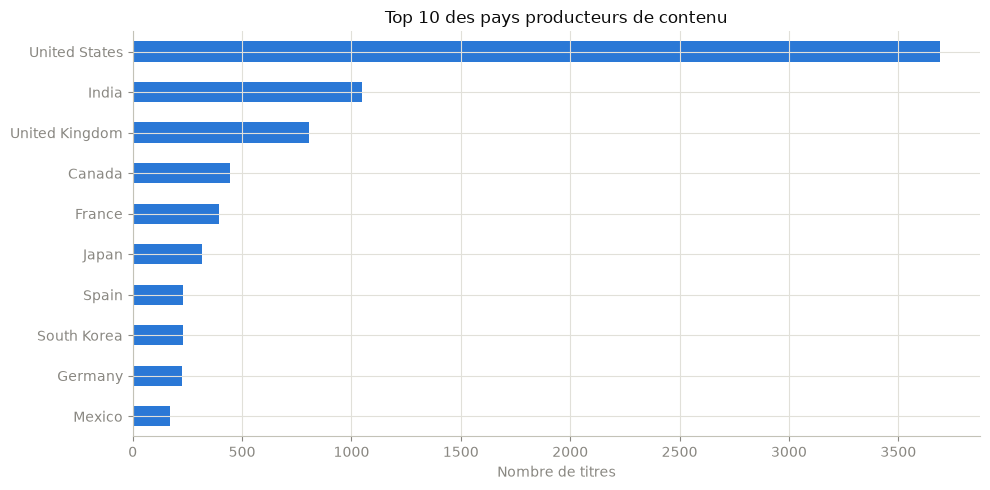

In [20]:
# Viz 3 : top 10 pays producteurs
fig, ax = plt.subplots(figsize=(10,5))
pays.value_counts().head(10).sort_values().plot.barh(ax=ax, color=BLEU)
ax.set_title('Top 10 des pays producteurs de contenu')
ax.set_xlabel('Nombre de titres'); ax.set_ylabel('')
fig.savefig('visualisations/viz3_top_pays.png', dpi=120)
plt.show()

**Constat :** les États-Unis dominent largement (3 689 titres), suivis de l'Inde (1 046) et du Royaume-Uni (804) - mais la présence du Japon, de la Corée du Sud et du Mexique dans le top 10 illustre la stratégie d'internationalisation de Netflix.

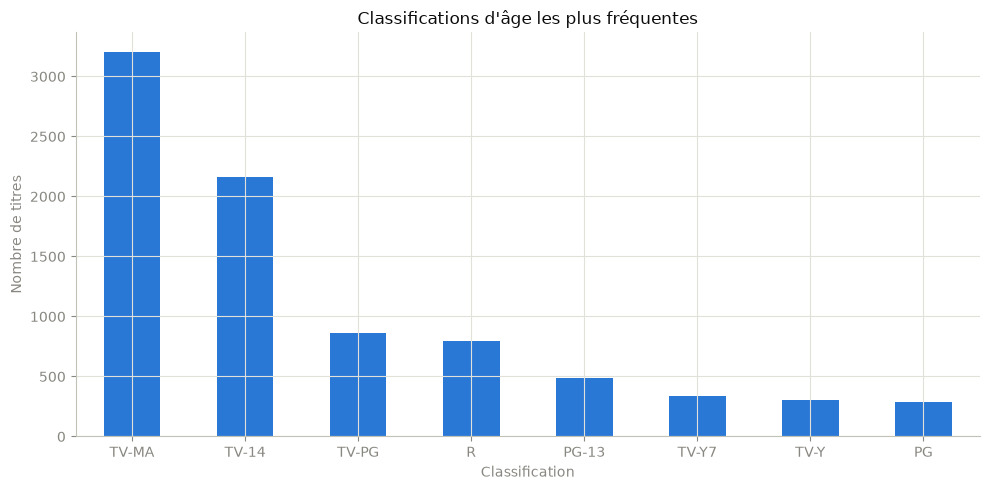

In [21]:
# Viz 4 : classifications d'âge
fig, ax = plt.subplots(figsize=(10,5))
data[data['rating']!='Unknown']['rating'].value_counts().head(8).plot.bar(ax=ax, color=BLEU)
ax.set_title('Classifications d\'âge les plus fréquentes')
ax.set_xlabel('Classification'); ax.set_ylabel('Nombre de titres')
plt.xticks(rotation=0)
fig.savefig('visualisations/viz4_ratings.png', dpi=120)
plt.show()

**Constat :** TV-MA (adultes) et TV-14 (ados) totalisent 61 % du catalogue - Netflix cible d'abord un public adulte.

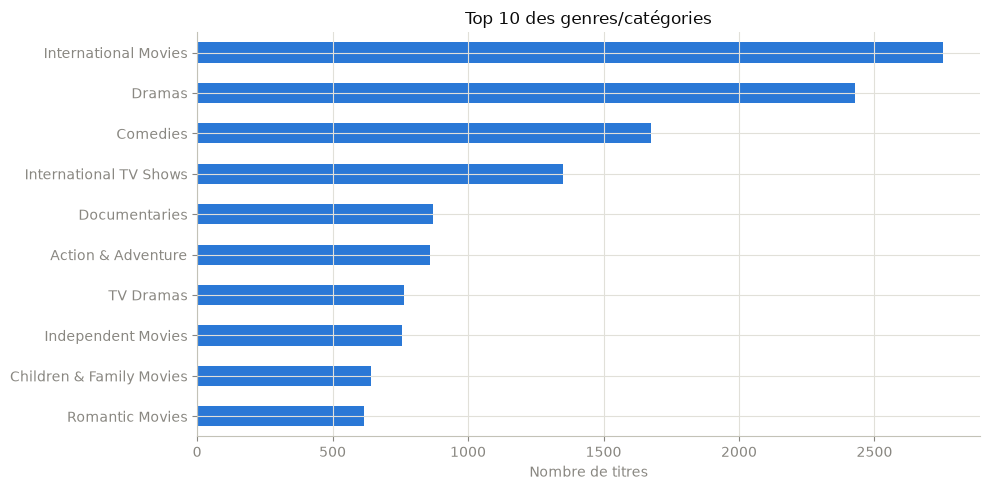

In [22]:
# Viz 5 : top 10 genres
fig, ax = plt.subplots(figsize=(10,5))
genres.value_counts().head(10).sort_values().plot.barh(ax=ax, color=BLEU)
ax.set_title('Top 10 des genres/catégories')
ax.set_xlabel('Nombre de titres'); ax.set_ylabel('')
fig.savefig('visualisations/viz5_top_genres.png', dpi=120)
plt.show()

**Constat :** « International Movies » (2 752) et « Dramas » (2 427) arrivent en tête - le contenu international est le premier segment du catalogue.

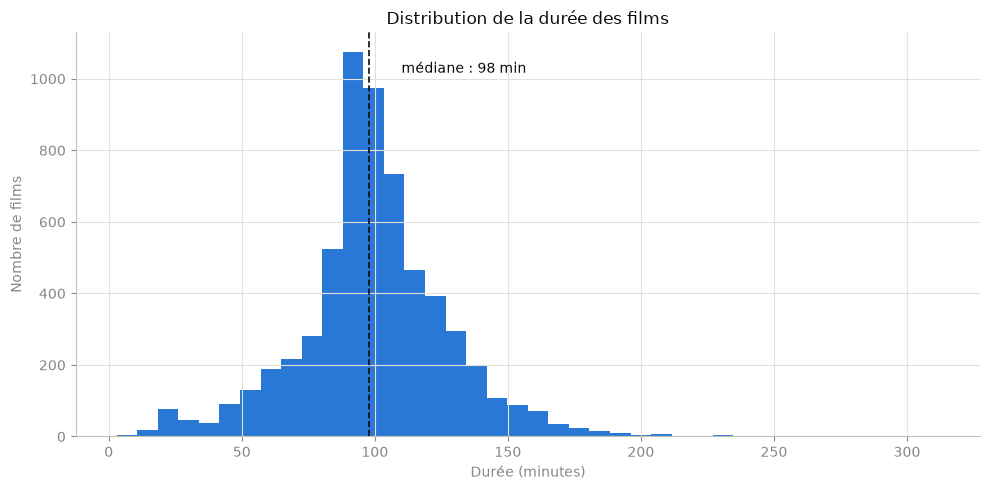

In [23]:
# Viz 6 : distribution de la durée des films
fig, ax = plt.subplots(figsize=(10,5))
data[data['type']=='Movie']['duration_valeur'].plot.hist(bins=40, ax=ax, color=BLEU)
ax.axvline(98, color=ENCRE, linewidth=1.2, linestyle='--')
ax.annotate('médiane : 98 min', xy=(98, ax.get_ylim()[1]*0.9), xytext=(110, ax.get_ylim()[1]*0.9), color=ENCRE)
ax.set_title('Distribution de la durée des films')
ax.set_xlabel('Durée (minutes)'); ax.set_ylabel('Nombre de films')
fig.savefig('visualisations/viz6_duree_films.png', dpi=120)
plt.show()

**Constat :** la durée des films se concentre autour de 90-100 minutes (médiane 98 min), avec quelques extrêmes de 3 à 312 minutes.

## Tâche 5 - Insights clés

**1. Un catalogue dominé par les films, mais des séries stratégiques.** Les films représentent 69,6 % des titres. Les séries, elles, fidélisent : 67 % n'ont qu'une seule saison, signe d'un flux constant de nouveautés et de nombreux tests de concepts (viz. 1).

**2. L'expansion s'est arrêtée net en 2020.** Après une croissance fulgurante de 2016 à 2019 (pic à ~2 000 ajouts/an), les ajouts reculent en 2020-2021 : l'effet de la pandémie sur la production mondiale de contenus est directement visible dans les données (viz. 2).

**3. Une plateforme américaine en voie de mondialisation.** Les États-Unis produisent encore 3 à 4 fois plus que tout autre pays, mais l'Inde est déjà 2e et le premier genre du catalogue est « International Movies ». La croissance de Netflix se joue hors des États-Unis (viz. 3 et 5).

**4. Un positionnement clairement adulte.** 61 % des titres sont classés TV-MA ou TV-14. Le contenu jeunesse (TV-Y, TV-G...) reste minoritaire : Netflix n'est pas d'abord une plateforme familiale (viz. 4).

**5. Le format standard du film reste 1 h 40.** Médiane à 98 minutes, distribution resserrée autour de 90-100 min : malgré la liberté du streaming, la durée du cinéma traditionnel reste la norme (viz. 6).

---
*Notebook réalisé dans le cadre du stage AnalystLab Africa - Semaines 1 & 2.*